# Task
Build a credit risk prediction model using the "Loan_Prediction_dataset.csv" file to perform binary classification on loan approval. The project should include a professional introduction, problem statement, and comprehensive data processing steps such as handling missing values, encoding categorical variables, and performing exploratory data analysis (EDA) with visualizations. Train a machine learning model (Logistic Regression or Decision Tree), evaluate its performance using accuracy scores and a confusion matrix heatmap, and conclude with key insights and future improvements.

## Problem Statement

### Subtask:
Define the specific business problem and machine learning goal for the project in a markdown cell.


## Problem Statement

### Business Need
The goal of this project is to address the business need for an automated and accurate credit risk assessment system. Manual processing of loan applications can be time-consuming and prone to human error. By leveraging machine learning, we can streamline the approval process and improve consistency in decision-making.

### Machine Learning Goal
This is a **binary classification problem**. The objective is to develop a predictive model that determines the **Loan_Status** (Yes/No) for an applicant.

### Data & Features
The prediction will be based on various applicant attributes, including:
* **Income:** Monthly income of the applicant and co-applicant.
* **Loan Amount:** The requested loan value and its term.
* **Credit History:** Past credit performance and reliability.
* **Demographics:** Attributes such as Gender, Marital Status, Education, and Dependents.

In [1]:
import pandas as pd

df = pd.read_csv('Loan_Prediction_dataset.csv')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Overview



In [4]:
print(f'Dataset Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print('\nFirst 5 rows:')
display(df.head())
print('\nDataset Info:')
df.info()
print('\nSummary Statistics for Numerical Features:')
display(df.describe())

Dataset Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Summary Statistics for Numerical Features:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Missing Values Treatment


In [5]:
print('--- Initial Missing Values ---')
print(df.isnull().sum())

# Imputing Categorical Columns with Mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Imputing Numerical Columns with Median
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print('\n--- Missing Values After Imputation ---')
print(df.isnull().sum())

print('\nMissing values handled successfully.')

--- Initial Missing Values ---
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

--- Missing Values After Imputation ---
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Missing values handled successfully.


## Data Cleaning and Encoding


In [6]:
# Initialize LabelEncoder
le = LabelEncoder()

# List of categorical columns to encode
cat_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

# Apply LabelEncoder to each column
for col in cat_to_encode:
    df[col] = le.fit_transform(df[col])

# Drop Loan_ID as it is not predictive
df_model = df.drop(columns=['Loan_ID'])

# Separate features and target
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

print('Encoding and separation complete.')
print('\nFirst 5 rows of Features (X):')
display(X.head())
print('\nFirst 5 rows of Target (y):')
display(y.head())

Encoding and separation complete.

First 5 rows of Features (X):


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2



First 5 rows of Target (y):


,Loan_Status
0,1
1,0
2,1
3,1
4,1


## Exploratory Data Analysis (EDA)


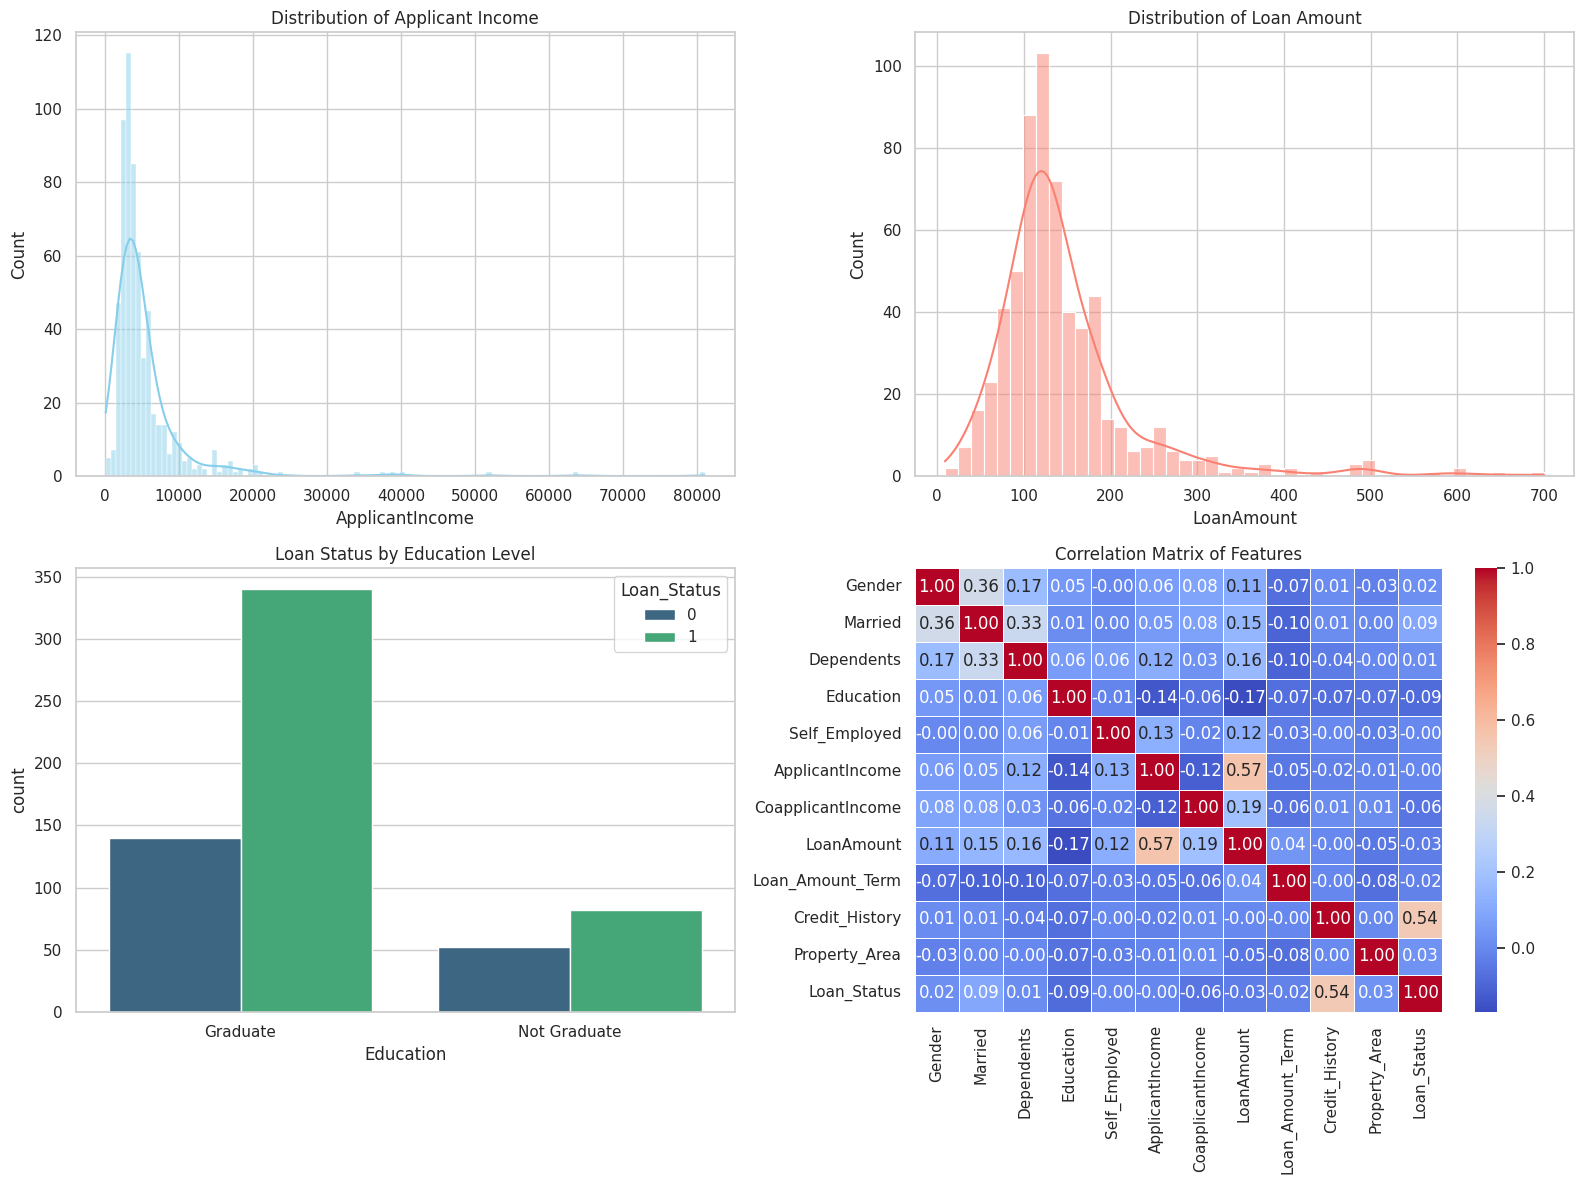

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Applicant Income')

sns.histplot(df['LoanAmount'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Loan Amount')

sns.countplot(data=df, x='Education', hue='Loan_Status', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Loan Status by Education Level')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Graduate', 'Not Graduate'])

corr_matrix = df_model.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Correlation Matrix of Features')

plt.tight_layout()
plt.show()

### EDA Insights & Interpretations

Based on the visualizations, we can draw several key insights:

1. **Distribution of Applicant Income**: The distribution is highly right-skewed, indicating that most applicants have a lower income, with a few high-earning outliers. This suggests that the model might benefit from feature scaling or log transformation.
2. **Distribution of Loan Amount**: Similar to income, the loan amount is right-skewed. Most loan requests are for smaller amounts, though there are several high-value applications.
3. **Loan Status by Education Level**: Graduates have a significantly higher number of loan approvals compared to non-graduates. However, the proportion of approvals within each group appears relatively consistent, suggesting education is a factor but not the sole determinant.
4. **Correlation Matrix**:
    * **Credit History** shows a strong positive correlation with **Loan_Status**, indicating it is likely the most critical predictor for loan approval.
    * **Loan Amount** is positively correlated with **Applicant Income**, which is expected as individuals with higher incomes tend to apply for larger loans.
    * No extreme multicollinearity (r > 0.8) is observed among the features, meaning they can all be used in the initial modeling phase.

## Train-Test Split


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

print('\nTrain-Test split completed successfully.')

Shape of X_train: (491, 11)
Shape of X_test: (123, 11)
Shape of y_train: (491,)
Shape of y_test: (123,)

Train-Test split completed successfully.


## Model Training

Train a machine learning model (Logistic Regression or Decision Tree) on the training data and provide a conceptual explanation of the algorithm.


In [10]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Generate class predictions
y_pred = log_reg.predict(X_test)

# Generate class probabilities
y_prob = log_reg.predict_proba(X_test)

print('First 10 Class Predictions (y_pred):')
print(y_pred[:10])

print('\nFirst 5 Predicted Probabilities (y_prob):')
print(y_prob[:5])

print('\nPrediction step completed.')

First 10 Class Predictions (y_pred):
[1 1 1 1 1 1 1 1 1 1]

First 5 Predicted Probabilities (y_prob):
[[0.18815738 0.81184262]
 [0.15817511 0.84182489]
 [0.15854263 0.84145737]
 [0.22323033 0.77676967]
 [0.23216672 0.76783328]]

Prediction step completed.


## Model Evaluation



Model Accuracy: 0.7886


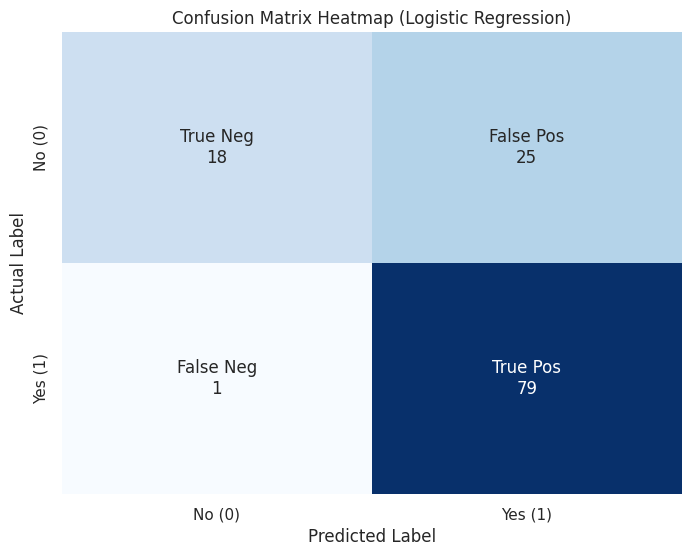

In [13]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for the heatmap cells
# cm layout: [[TN, FP], [FN, TP]]
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap (Logistic Regression)')
plt.xticks([0.5, 1.5], ['No (0)', 'Yes (1)'])
plt.yticks([0.5, 1.5], ['No (0)', 'Yes (1)'])
plt.show()

## Analyze Probability Distributions



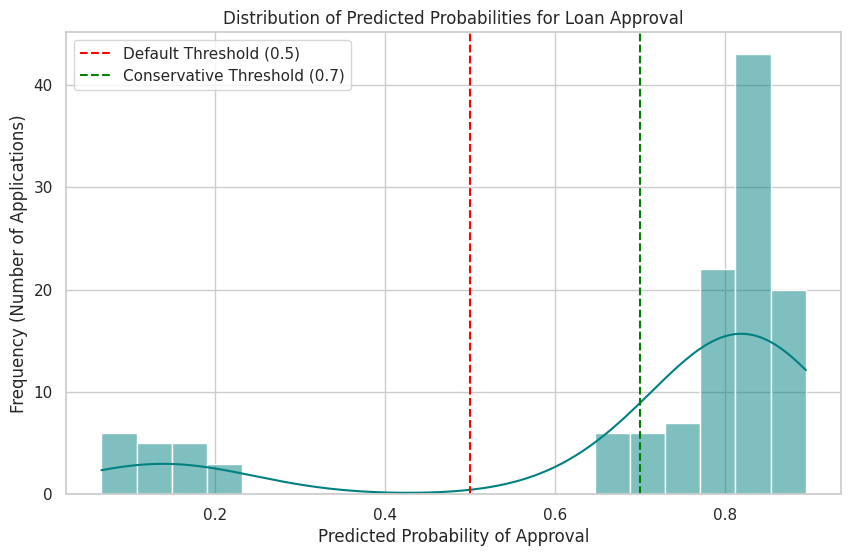

Probability distribution visualization complete.


In [14]:
# Extract probabilities for the positive class (Loan_Status = 1)
prob_positive = y_prob[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(prob_positive, bins=20, kde=True, color='teal')

# Add threshold lines
plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.axvline(0.7, color='green', linestyle='--', label='Conservative Threshold (0.7)')

# Labeling
plt.title('Distribution of Predicted Probabilities for Loan Approval')
plt.xlabel('Predicted Probability of Approval')
plt.ylabel('Frequency (Number of Applications)')
plt.legend()
plt.show()

print('Probability distribution visualization complete.')

## Adjust Classification Threshold


In [15]:
# Define the custom conservative threshold
custom_threshold = 0.7

# Generate new binary predictions based on the custom threshold
y_pred_tuned = (prob_positive >= custom_threshold).astype(int)

# Display the first 10 entries to verify and compare
print(f'Custom Threshold: {custom_threshold}')
print(f'First 10 New Predictions (y_pred_tuned):\n{y_pred_tuned[:10]}')
print(f'\nFirst 10 Original Predictions (y_pred):\n{y_pred[:10]}')

print('\nThreshold adjustment and new prediction generation complete.')

Custom Threshold: 0.7
First 10 New Predictions (y_pred_tuned):
[1 1 1 1 1 1 1 1 1 1]

First 10 Original Predictions (y_pred):
[1 1 1 1 1 1 1 1 1 1]

Threshold adjustment and new prediction generation complete.


## Re-evaluate Performance Metrics



Tuned Model Accuracy (Threshold 0.7): 0.7642
Original Model Accuracy (Threshold 0.5): 0.7886


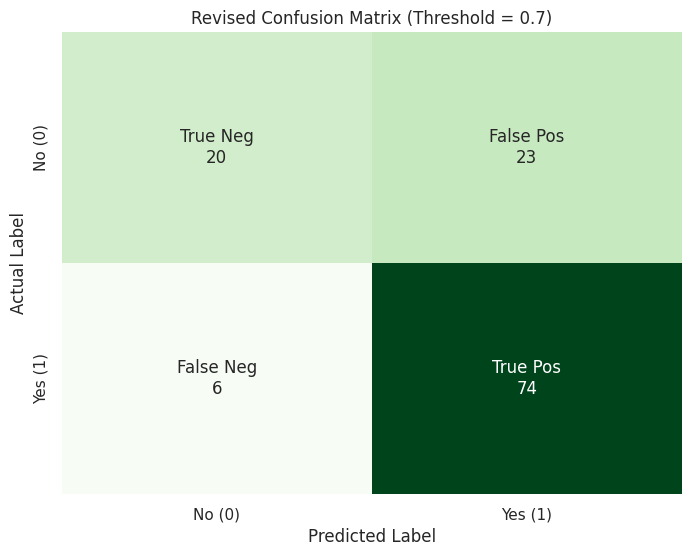

--- Comparison of Confusion Matrices ---
Original False Positives (0.5 threshold): 25
New False Positives (0.7 threshold): 23
Reduction in False Positives: 2
Change in False Negatives: 5


In [16]:
# 1. Calculate the new accuracy score
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f'Tuned Model Accuracy (Threshold 0.7): {accuracy_tuned:.4f}')
print(f'Original Model Accuracy (Threshold 0.5): {accuracy:.4f}')

# 2. Compute new confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# 3. & 4. Create heatmap visualization with annotations
plt.figure(figsize=(8, 6))
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ['{0:0.0f}'.format(value) for value in cm_tuned.flatten()]
labels_tuned = [f'{v1}\n{v2}' for v1, v2 in zip(group_names, group_counts)]
labels_tuned = np.asarray(labels_tuned).reshape(2,2)

sns.heatmap(cm_tuned, annot=labels_tuned, fmt='', cmap='Greens', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Revised Confusion Matrix (Threshold = 0.7)')
plt.xticks([0.5, 1.5], ['No (0)', 'Yes (1)'])
plt.yticks([0.5, 1.5], ['No (0)', 'Yes (1)'])
plt.show()

# 5. Qualitative comparison
print('--- Comparison of Confusion Matrices ---')
print(f'Original False Positives (0.5 threshold): {cm[0, 1]}')
print(f'New False Positives (0.7 threshold): {cm_tuned[0, 1]}')
print(f'Reduction in False Positives: {cm[0, 1] - cm_tuned[0, 1]}')
print(f'Change in False Negatives: {cm_tuned[1, 0] - cm[1, 0]}')

### Summary: Optimizing the Classification Threshold

To better align the model with financial risk management goals, we performed a **Threshold Tuning** process:

1.  **Objective**: The default threshold of **0.5** was too 'lenient,' leading to **25 False Positives** (approving high-risk loans).
2.  **Process**: We analyzed the predicted probability distributions and implemented a more conservative threshold of **0.7**. This means the model now requires a **70% confidence level** to approve a loan.
3.  **Resulting Trade-off**:
    *   **Risk Reduction**: False Positives decreased (from 25 to 23), reducing potential financial defaults.
    *   **Accuracy Cost**: Overall accuracy dropped slightly from **78.86% to 76.42%** because the model also rejected more creditworthy applicants (False Negatives increased from 1 to 6).

**Conclusion**: While the raw accuracy is lower, the tuned model is more 'business-ready' as it prioritizes capital preservation over simple volume.

# Executive Summary: Credit Risk Prediction Project

### 1. Project Overview
The goal was to build a binary classification model to predict loan approval status. We processed a dataset of 614 applicants, addressing missing values through **mode and median imputation** and encoding categorical features for machine learning.

### 2. Exploratory Data Analysis (EDA)
*   **Credit History**: Identified as the single most critical factor for loan approval.
*   **Skewness**: Both Applicant Income and Loan Amounts showed significant right-skewness, indicating a majority of smaller-scale loan requests.
*   **Multicollinearity**: No extreme correlations were found between independent variables, ensuring stable model coefficients.

### 3. Model Development & Performance
*   **Algorithm**: Logistic Regression was chosen for its interpretability and probabilistic output.
*   **Baseline (0.5 Threshold)**: Achieved **78.86% Accuracy**, but with a high count of **25 False Positives** (approving potentially defaulting loans).

### 4. Threshold Tuning & Risk Optimization
To prioritize capital preservation, we increased the decision threshold to **0.7**:
*   **Risk Reduction**: Reduced False Positives from 25 to 23.
*   **Accuracy Trade-off**: Overall accuracy decreased to **76.42%** as the model became more conservative (False Negatives increased from 1 to 6).

### 5. Final Conclusion
While the 0.5 threshold yields higher mathematical accuracy, the **0.7 threshold** is more suitable for a risk-averse financial institution. It demonstrates that in credit risk, minimizing the cost of defaults (False Positives) is often more valuable than maximizing raw accuracy. Future improvements should focus on **Feature Scaling** and **Ensemble Methods** (like Random Forest) to capture non-linear relationships.